In [9]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import List, Optional, Union, Tuple, Dict

In [10]:
# config -- 
LESS_SEVERE_RHO_VALUES_CSV = "less_severe_rho_values_mean.csv"
LESS_SEVERE_P_VALUES_CSV = "less_severe_p_values_mean.csv"
SEVERE_RHO_VALUES_CSV = "severe_rho_values_mean.csv"
SEVERE_P_VALUES_CSV = "severe_p_values_mean.csv"

PATH_COLS_TO_DROP = []
LESS_SEVERE_SAVE_FILE = "figures_v2/3/agg_less_severe_in_vitro_correlations.svg"
SEVERE_SAVE_FILE = "figures_v2/3/agg_severe_in_vitro_correlations.svg"


ALPHA = 0.05

FLIPPED_FEATURES = []

In [11]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [12]:
from collections import OrderedDict
import re
import matplotlib.colors as mcolors

class CorrelationHeatmapPlotter:
    """
    Enhanced correlation plotting class that creates heatmap-style plots 
    for rho and p values with configurable rows and grouped X values.
    """
    
    def __init__(self, 
                 less_severe_rho_file: str,
                 less_severe_p_file: str,
                 severe_rho_file: str,
                 severe_p_file: str,
                 alpha: float = 0.05):
        """
        Initialize with separate files for rho and p values for both severity levels.
        """
        self.less_severe_rho = self._load_and_align(less_severe_rho_file)
        self.less_severe_p = self._load_and_align(less_severe_p_file)
        self.severe_rho = self._load_and_align(severe_rho_file)
        self.severe_p = self._load_and_align(severe_p_file)
        self.alpha = alpha
        
        # Get available pathology columns (excluding feature columns)
        self.pathology_columns = [col for col in self.less_severe_rho.columns 
                                 if col not in ['feature', 'feature_key']]
        
        # Define color scheme for different metrics
        self.metric_colors = {
            'AUC': '#2E8B57',      # SeaGreen
            'Einf': '#FF8C00',     # DarkOrange  
            'FxC': '#FF1493',      # DeepPink (for FIC/FBC)
            'GRmax': '#8A2BE2',    # BlueViolet
            'default': '#000000'   # Black for unrecognized metrics
        }
    
    def _load_and_align(self, filepath: str) -> pd.DataFrame:
        """Load CSV and create aligned feature keys."""
        df = pd.read_csv(filepath)
        df = self._build_alignment(df)
        return df
    
    def _build_alignment(self, df: pd.DataFrame) -> pd.DataFrame:
        """Build feature alignment similar to correlations_plotting.ipynb."""
        df = df.copy()
        feat_col = next((c for c in df.columns if str(c).strip().lower() == "in_vitro_feature"), df.columns[0])
        df.rename(columns={feat_col: "feature"}, inplace=True)
        df["feature_key"] = df["feature"].map(self._canonical_feature)
        return df
    
    def _canonical_feature(self, s: str) -> Optional[str]:
        """Return canonical key for EQ/PK/LID features."""
        if s is None or (isinstance(s, float) and np.isnan(s)):
            return None
        s0 = str(s).strip()

        # LIDs (p-style; allow trailing spaces)
        m = re.match(r"^(?P<prefix>[57][NH])\s+(?P<pk>(?:casPK|cellPK|equip))\s+(?P<metric>AUC\d+|FBC\d+)\s*$",
                        s0, re.IGNORECASE)
        if m:
            return f"LID|{m.group('prefix').upper()}|{m.group('pk').lower()}|{m.group('metric').upper()}"

        # LIDs (rho-style variants)
        m = re.match(r"^(?P<prefix>[57][NH])\s*PK(?P<pk>cas|cell|equip)(?P<metric>AUC\d+|FBC\d+)\s*$",
                        s0, re.IGNORECASE)
        if m:
            return f"LID|{m.group('prefix').upper()}|{m.group('pk').lower()}|{m.group('metric').upper()}"

        # PK (rho-style) with OPTIONAL phase
        m = re.match(r"^PK(?P<which>cas|cell)(?P<subs>[A-Za-z]+)(?P<metric>AUC\d+|GRinf)(?P<phase>CT|C|T)?$",
                        s0, re.IGNORECASE)
        if m:
            which = m.group("which").lower()
            subs = m.group("subs").lower()
            metric = m.group("metric").upper()
            phase = (m.group("phase") or "").upper()
            return f"PK|{which}|{subs}|{metric}|{phase}"

        # PK (p-style)
        m = re.match(r"^PK_(?P<which>cas|cell)\s+(?P<metric>AUC\d+|GRinf)\s+(?P<subs>[A-Za-z]+)\s*\((?P<phase>[^)]+)\)\s*$",
                        s0, re.IGNORECASE)
        if m:
            return f"PK|{m.group('which').lower()}|{m.group('subs').lower()}|{m.group('metric').upper()}|{self._abbr_phase(m.group('phase'))}"

        # EQ (rho-style) with OPTIONAL phase
        m = re.match(r"^(?P<subs>[A-Za-z]+)(?P<metric>AUC\d+|FIC\d+|FBC\d+|GRinf)(?P<phase>CT|C|T)?$",
                        s0, re.IGNORECASE)
        if m:
            subs = m.group("subs").lower()
            metric = m.group("metric").upper()
            phase = (m.group("phase") or "").upper()
            return f"EQ|{metric}|{subs}|{phase}"

        # EQ (p-style)
        m = re.match(r"^(?P<metric>[A-Z]+[0-9]*|GRinf)\s+(?P<subs>[A-Za-z]+)\s*\((?P<phase>[^)]+)\)",
                        s0, re.IGNORECASE)
        if m:
            return f"EQ|{m.group('metric').upper()}|{m.group('subs').lower()}|{self._abbr_phase(m.group('phase'))}"

        return None
    
    def _abbr_phase(self, text: str) -> str:
        """Abbreviate phase descriptions."""
        t = str(text).strip().lower()
        if "constant" in t and "terminal" in t:
            return "CT"
        if "constant" in t:
            return "C"
        if "terminal" in t:
            return "T"
        return t[:1].upper() if t else ""
    
    def _extract_metric_type(self, feature: str) -> str:
        """Extract metric type from feature name for color coding."""
        feature_upper = feature.upper()
        
        # Check for specific patterns - more comprehensive matching
        if 'AUC' in feature_upper:
            return 'AUC'
        elif 'EINF' in feature_upper or 'E_INF' in feature_upper:
            return 'Einf'
        elif any(pattern in feature_upper for pattern in ['FIC', 'FBC', 'F50', 'F90', 'FC50', 'FC90']):
            return 'FxC'
        elif 'GRMAX' in feature_upper or 'GR_MAX' in feature_upper or 'GR MAX' in feature_upper:
            return 'GRmax'
        else:
            return 'default'
    
    def _get_feature_colors(self, features: List[str]) -> List[str]:
        """Get color list for features based on their metric type."""
        colors = []
        for feature in features:
            metric_type = self._extract_metric_type(feature)
            colors.append(self.metric_colors[metric_type])
        return colors
    
    def _classify_feature_condition(self, feature: str) -> str:
        """Classify feature into simple equipotent, simple PK, or LIDS based on condition."""
        feature_lower = feature.lower()
        
        # LIDS: features containing "5n", "7n", or "7h"
        if any(lid_marker in feature_lower for lid_marker in ["5n", "7n", "7h"]):
            return "LIDS"
        
        # Simple PK: features containing "cellpk" or "caspk" (but not LIDS markers)
        elif any(pk_marker in feature_lower for pk_marker in ["cellpk", "caspk"]):
            return "simple PK"
        
        # Simple equipotent: everything else
        else:
            return "simple equipotent"
    
    def _extract_condition_timepoint(self, feature: str) -> tuple:
        """Extract condition and timepoint from feature name for sorting."""
        feature_lower = feature.lower()
        
        # Try to extract timepoint (like C, T, CT at the end)
        timepoint = ""
        if feature_lower.endswith("ct"):
            timepoint = "CT"
        elif feature_lower.endswith("c"):
            timepoint = "C"
        elif feature_lower.endswith("t"):
            timepoint = "T"
        
        # Remove timepoint from condition for cleaner grouping
        condition = feature
        if timepoint:
            condition = feature[:-len(timepoint)].strip()
        
        return condition, timepoint
    
    def _categorize_feature(self, features: List[str]) -> Dict[str, List[str]]:
        """Categorize and sort features by condition-timepoint groupings."""
        
        # First, classify all features
        classified = {}
        for feature in features:
            classification = self._classify_feature_condition(feature)
            condition, timepoint = self._extract_condition_timepoint(feature)
            
            if classification not in classified:
                classified[classification] = {}
            if condition not in classified[classification]:
                classified[classification][condition] = []
            
            classified[classification][condition].append(feature)
        
        # Now organize in the requested order
        ordered_categories = OrderedDict()
        
        # Process in order: simple equipotent, simple PK, LIDS
        for classification in ["simple equipotent", "simple PK", "LIDS"]:
            if classification in classified:
                # Sort conditions alphabetically within each classification
                sorted_conditions = sorted(classified[classification].keys())
                
                for condition in sorted_conditions:
                    # Sort features within each condition (to handle multiple timepoints consistently)
                    sorted_features = sorted(classified[classification][condition])
                    
                    # Create a unique key for this condition group
                    group_key = f"{classification} - {condition}"
                    ordered_categories[group_key] = sorted_features
        
        return ordered_categories
    
    def _pretty_metric(self, metric: str) -> str:
        """Format metric names for display."""
        m = metric.upper()
        if m.startswith("FIC") or m.startswith("FBC"):
            return "FxC" + re.sub(r"\D", "", m)
        if m.startswith("AUC"):
            return "AUC" + re.sub(r"\D", "", m)
        if m.startswith("GRINF"):
            return "GRinf"
        return m
    
    def _clean_feature_names(self, features: List[str]) -> List[str]:
        """Clean feature names for display."""
        cleaned = []
        for feature in features:
            clean_name = feature.replace("(constant)", "C").replace("(terminal)", "T")
            clean_name = re.sub(r'\s+', ' ', clean_name).strip()
            cleaned.append(clean_name)
        return cleaned
    
    def _apply_colored_xlabels(self, ax: plt.Axes, labels: List[str], colors: List[str]):
        """Apply colored labels to x-axis."""
        # Set the labels first
        ax.set_xticklabels(labels, rotation=90)
        
        # Get the tick labels and apply colors
        for tick_label, color in zip(ax.get_xticklabels(), colors):
            tick_label.set_color(color)
            tick_label.set_weight('bold')  # Make them bold for better visibility
    
    def create_legend(self, 
                     cmap_colors: Tuple[str, str] = ("#d73027", "#4575b4"),
                     figsize: Tuple[float, float] = (8, 1),
                     orientation: str = 'horizontal',
                     include_metric_legend: bool = True) -> plt.Figure:
        """Create a separate legend figure for the correlation heatmaps."""
        
        colors = [cmap_colors[0], 'grey', cmap_colors[1]]
        cmap = LinearSegmentedColormap.from_list('custom', colors, N=256)
        
        if include_metric_legend:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(figsize[0], figsize[1]*2))
        else:
            fig, ax1 = plt.subplots(figsize=figsize)
        
        # Create a dummy heatmap just for the colorbar
        dummy_data = np.linspace(-1, 1, 100).reshape(1, -1)
        
        im = ax1.imshow(dummy_data, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
        ax1.set_visible(False)  # Hide the dummy plot
        
        if orientation == 'horizontal':
            cbar = fig.colorbar(im, ax=ax1, orientation='horizontal', pad=0.1, shrink=0.8)
            cbar.set_label('Spearman ρ', fontsize=12)
        else:
            cbar = fig.colorbar(im, ax=ax1, orientation='vertical', pad=0.1, shrink=0.8)
            cbar.set_label('Spearman ρ', fontsize=12, rotation=270, labelpad=20)
        
        # Add metric color legend
        if include_metric_legend:
            ax2.set_xlim(0, 1)
            ax2.set_ylim(0, 1)
            ax2.axis('off')
            
            # Create metric legend
            legend_elements = []
            for metric, color in self.metric_colors.items():
                if metric != 'default':  # Skip default color
                    legend_elements.append(
                        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=color, 
                                 markersize=10, label=metric, markeredgecolor='black')
                    )
            
            ax2.legend(handles=legend_elements, loc='center', ncol=len(legend_elements), 
                      title='Metric Types', title_fontsize=12, fontsize=10)
        
        plt.tight_layout()
        return fig
    
    def get_feature_sample(self, n_samples: int = 10) -> List[str]:
        """Get a sample of feature names to help with debugging metric detection."""
        all_features = self.less_severe_rho['feature'].tolist()
        return all_features[:n_samples] if len(all_features) > n_samples else all_features
    
    def debug_metric_detection(self, features: Optional[List[str]] = None) -> Dict[str, List[str]]:
        """Debug metric detection by showing which features are assigned to which colors."""
        if features is None:
            features = self.get_feature_sample()
        
        results = {}
        for metric_type in self.metric_colors.keys():
            results[metric_type] = []
        
        for feature in features:
            detected_type = self._extract_metric_type(feature)
            results[detected_type].append(feature)
        
        return results
    
    def _prepare_data_matrix(self, rho_df: pd.DataFrame, p_df: pd.DataFrame, 
                            pathology_rows: List[str], ordered_features: List[str], 
                            plot_type: str = 'rho'):
        """Prepare data matrix for a single severity level."""
        n_rows = len(pathology_rows)
        n_cols = len(ordered_features)
        
        if plot_type == 'rho':
            data_matrix = np.full((n_rows, n_cols), np.nan)
            mask_matrix = np.full((n_rows, n_cols), True, dtype=bool)
            
            for i, path_col in enumerate(pathology_rows):
                for j, feature in enumerate(ordered_features):
                    # Get rho and p values
                    rho_val = self._get_value(rho_df, feature, path_col)
                    p_val = self._get_value(p_df, feature, path_col)
                    
                    # Show rho if p < alpha
                    if rho_val is not None and p_val is not None and p_val < self.alpha:
                        data_matrix[i, j] = rho_val
                        mask_matrix[i, j] = False
            
            return data_matrix, mask_matrix
            
        elif plot_type == 'p':
            data_matrix = np.full((n_rows, n_cols), np.nan)
            mask_matrix = np.full((n_rows, n_cols), True, dtype=bool)
            
            for i, path_col in enumerate(pathology_rows):
                for j, feature in enumerate(ordered_features):
                    p_val = self._get_value(p_df, feature, path_col)
                    
                    if p_val is not None:
                        data_matrix[i, j] = p_val
                        mask_matrix[i, j] = False
            
            return data_matrix, mask_matrix
    
    def create_individual_heatmap(self,
                                 severity: str = 'less_severe',  # 'less_severe' or 'severe'
                                 pathology_rows: Optional[List[str]] = None,
                                 include_features: Optional[List[str]] = None,
                                 exclude_features: Optional[List[str]] = None,
                                 plot_type: str = 'rho',  # 'rho' or 'p'
                                 figsize: Tuple[int, int] = (20, 6),
                                 cmap_colors: Tuple[str, str] = ("#d73027", "#4575b4"),
                                 title: Optional[str] = None,
                                 add_grid: bool = True,
                                 color_xlabels: bool = True) -> Tuple[plt.Figure, plt.Axes]:
        """
        Create a single heatmap for either less severe or severe lesions.
        
        Parameters:
        -----------
        severity : str
            'less_severe' or 'severe'
        pathology_rows : List[str], optional
            Which pathology columns to include as rows
        include_features : List[str], optional
            Which features to include
        exclude_features : List[str], optional
            Which features to exclude
        plot_type : str
            'rho' for correlation values, 'p' for p-values
        figsize : Tuple[int, int]
            Figure size
        cmap_colors : Tuple[str, str]
            Colors for the colormap (negative, positive)
        title : str, optional
            Plot title (auto-generated if None)
        add_grid : bool
            Whether to add grid lines to the plot
        color_xlabels : bool
            Whether to color-code X-axis labels by metric type
        """
        
        # Select data based on severity
        if severity == 'less_severe':
            rho_df = self.less_severe_rho
            p_df = self.less_severe_p
            severity_label = "Less Severe Lesions"
        else:
            rho_df = self.severe_rho
            p_df = self.severe_p
            severity_label = "Severe Lesions"
        
        # Filter pathology columns
        if pathology_rows is None:
            pathology_rows = self.pathology_columns
        else:
            pathology_rows = [col for col in pathology_rows if col in self.pathology_columns]
        
        # Get features
        all_features = rho_df['feature'].tolist()
        
        # Filter features
        if include_features is not None:
            features = [f for f in include_features if f in all_features]
        else:
            features = all_features.copy()
        
        if exclude_features is not None:
            features = [f for f in features if f not in exclude_features]
        
        # Categorize and order features by condition-timepoint
        feature_categories = self._categorize_feature(features)
        ordered_features, category_boundaries, pos = [], [], 0
        for category_key, cat_features in feature_categories.items():
            ordered_features.extend(cat_features)
            # Extract the main classification for labeling
            main_class = category_key.split(' - ')[0]
            category_boundaries.append((pos, pos + len(cat_features), main_class))
            pos += len(cat_features)
        
        # Merge adjacent categories with same classification for cleaner boundaries
        merged_boundaries = []
        current_start, current_end, current_class = None, None, None
        
        for start, end, class_name in category_boundaries:
            if current_class == class_name:
                # Extend current boundary
                current_end = end
            else:
                # Save previous boundary if exists
                if current_class is not None:
                    merged_boundaries.append((current_start, current_end, current_class))
                # Start new boundary
                current_start, current_end, current_class = start, end, class_name
        
        # Don't forget the last boundary
        if current_class is not None:
            merged_boundaries.append((current_start, current_end, current_class))
        
        # Prepare data matrix
        data_matrix, mask_matrix = self._prepare_data_matrix(
            rho_df, p_df, pathology_rows, ordered_features, plot_type
        )
        
        # Set up figure
        fig, ax = plt.subplots(figsize=figsize)
        
        # Set up colormap
        if plot_type == 'p':
            plot_cmap = 'viridis_r'
            vmin, vmax, center = 0, 1, None
        else:
            colors = [cmap_colors[0], 'grey', cmap_colors[1]]
            plot_cmap = LinearSegmentedColormap.from_list('custom', colors, N=256)
            vmin, vmax, center = -1, 1, 0
        
        # Clean feature names for display
        display_features = self._clean_feature_names(ordered_features)
        
        # Create heatmap
        sns.heatmap(data_matrix, mask=mask_matrix,
                   xticklabels=display_features, yticklabels=pathology_rows,
                   cmap=plot_cmap, vmin=vmin, vmax=vmax, center=center,
                   ax=ax, cbar=True, square=False)
        
        # Add colored X-axis labels if requested
        if color_xlabels:
            label_colors = self._get_feature_colors(ordered_features)
            self._apply_colored_xlabels(ax, display_features, label_colors)
        
        # Add grid lines if requested
        if add_grid:
            ax.grid(True, linestyle='-', alpha=0.3, color='white', linewidth=0.5)
            ax.set_axisbelow(True)
        
        # Set title
        if title is None:
            title = f"{severity_label} - {plot_type.upper()}"
        ax.set_title(title, fontsize=14, pad=50)
        
        # Set axis labels
        ax.set_xlabel("In vitro feature", fontsize=12)
        ax.set_ylabel("Pathology measure", fontsize=12)
        
        # Rotate x-axis labels
        ax.tick_params(axis="x", rotation=90)
        
        # Add category boundaries (vertical lines between main classifications)
        for start, end, _ in merged_boundaries[:-1]:  # Skip the last boundary
            ax.axvline(x=end, color="black", linewidth=3, ymin=0, ymax=1)
        
        # Add category labels below the plot
        for start, end, category in merged_boundaries:
            mid_pos = (start + end) / 2
            ax.text(mid_pos, -len(pathology_rows) * 0.15, category,
                   ha="center", va="top", fontsize=10, weight="bold")
        
        plt.tight_layout()
        
        return fig, ax
    
    def create_heatmaps(self,
                       pathology_rows: Optional[List[str]] = None,
                       include_features: Optional[List[str]] = None,
                       exclude_features: Optional[List[str]] = None,
                       plot_type: str = 'rho',  # 'rho', 'p', or 'both'
                       figsize: Tuple[int, int] = (20, 12),
                       cmap_colors: Tuple[str, str] = ("#d73027", "#4575b4"),
                       title: str = "In vitro feature correlations",
                       add_grid: bool = True,
                       color_xlabels: bool = True) -> Tuple[plt.Figure, Tuple[plt.Axes, ...]]:
        """
        Create heatmap plots for correlation data.
        
        Parameters:
        -----------
        pathology_rows : List[str], optional
            Which pathology columns to include as rows
        include_features : List[str], optional
            Which features to include
        exclude_features : List[str], optional
            Which features to exclude
        plot_type : str
            'rho' for correlation values, 'p' for p-values, 'both' for side-by-side
        figsize : Tuple[int, int]
            Figure size
        cmap_colors : Tuple[str, str]
            Colors for the colormap (negative, positive)
        title : str
            Plot title
        add_grid : bool
            Whether to add grid lines to the plots
        color_xlabels : bool
            Whether to color-code X-axis labels by metric type
        """
        
        # Filter pathology columns
        if pathology_rows is None:
            pathology_rows = self.pathology_columns
        else:
            pathology_rows = [col for col in pathology_rows if col in self.pathology_columns]
        
        # Get features from less severe data (assuming it has all features)
        all_features = self.less_severe_rho['feature'].tolist()
        
        # Filter features
        if include_features is not None:
            features = [f for f in include_features if f in all_features]
        else:
            features = all_features.copy()
        
        if exclude_features is not None:
            features = [f for f in features if f not in exclude_features]
        
        # Categorize and order features by condition-timepoint
        feature_categories = self._categorize_feature(features)
        ordered_features, category_boundaries, pos = [], [], 0
        for category_key, cat_features in feature_categories.items():
            ordered_features.extend(cat_features)
            # Extract the main classification for labeling
            main_class = category_key.split(' - ')[0]
            category_boundaries.append((pos, pos + len(cat_features), main_class))
            pos += len(cat_features)
        
        # Merge adjacent categories with same classification for cleaner boundaries
        merged_boundaries = []
        current_start, current_end, current_class = None, None, None
        
        for start, end, class_name in category_boundaries:
            if current_class == class_name:
                # Extend current boundary
                current_end = end
            else:
                # Save previous boundary if exists
                if current_class is not None:
                    merged_boundaries.append((current_start, current_end, current_class))
                # Start new boundary
                current_start, current_end, current_class = start, end, class_name
        
        # Don't forget the last boundary
        if current_class is not None:
            merged_boundaries.append((current_start, current_end, current_class))
        
        # Prepare data matrices
        def prepare_matrices(rho_df, p_df, severity_label):
            n_rows = len(pathology_rows)
            n_cols = len(ordered_features)
            
            if plot_type == 'rho':
                data_matrix = np.full((n_rows, n_cols), np.nan)
                mask_matrix = np.full((n_rows, n_cols), True, dtype=bool)
                
                for i, path_col in enumerate(pathology_rows):
                    for j, feature in enumerate(ordered_features):
                        # Get rho and p values
                        rho_val = self._get_value(rho_df, feature, path_col)
                        p_val = self._get_value(p_df, feature, path_col)
                        
                        # Show rho if p < alpha
                        if rho_val is not None and p_val is not None and p_val < self.alpha:
                            data_matrix[i, j] = rho_val
                            mask_matrix[i, j] = False
                
                return data_matrix, mask_matrix
                
            elif plot_type == 'p':
                data_matrix = np.full((n_rows, n_cols), np.nan)
                mask_matrix = np.full((n_rows, n_cols), True, dtype=bool)
                
                for i, path_col in enumerate(pathology_rows):
                    for j, feature in enumerate(ordered_features):
                        p_val = self._get_value(p_df, feature, path_col)
                        
                        if p_val is not None:
                            data_matrix[i, j] = p_val
                            mask_matrix[i, j] = False
                
                return data_matrix, mask_matrix
            
            else:  # both
                rho_matrix = np.full((n_rows, n_cols), np.nan)
                p_matrix = np.full((n_rows, n_cols), np.nan)
                rho_mask = np.full((n_rows, n_cols), True, dtype=bool)
                p_mask = np.full((n_rows, n_cols), True, dtype=bool)
                
                for i, path_col in enumerate(pathology_rows):
                    for j, feature in enumerate(ordered_features):
                        rho_val = self._get_value(rho_df, feature, path_col)
                        p_val = self._get_value(p_df, feature, path_col)
                        
                        if rho_val is not None and p_val is not None and p_val < self.alpha:
                            rho_matrix[i, j] = rho_val
                            rho_mask[i, j] = False
                        
                        if p_val is not None:
                            p_matrix[i, j] = p_val
                            p_mask[i, j] = False
                
                return (rho_matrix, rho_mask), (p_matrix, p_mask)
        
        # Prepare matrices for both severity levels
        less_severe_result = prepare_matrices(self.less_severe_rho, self.less_severe_p, "Less Severe")
        severe_result = prepare_matrices(self.severe_rho, self.severe_p, "Severe")
        
        # Set up figure
        if plot_type == 'both':
            fig, axes = plt.subplots(2, 2, figsize=(figsize[0]*1.5, figsize[1]),
                                   gridspec_kw={"hspace": 0.1, "wspace": 0.1})
            axes = axes.flatten()
        else:
            fig, axes = plt.subplots(2, 1, figsize=figsize,
                                   gridspec_kw={"hspace": 0.1, "height_ratios": [1, 1]})
        
        # Set up colormap
        colors = [cmap_colors[0], 'grey', cmap_colors[1]]
        cmap = LinearSegmentedColormap.from_list('custom', colors, N=256)
        
        # Clean feature names for display
        display_features = self._clean_feature_names(ordered_features)
        
        # Get colors for X-axis labels
        if color_xlabels:
            label_colors = self._get_feature_colors(ordered_features)
        
        # Plot heatmaps
        if plot_type == 'both':
            # Rho plots
            less_rho_data, less_rho_mask = less_severe_result[0]
            severe_rho_data, severe_rho_mask = severe_result[0]
            
            # P-value plots  
            less_p_data, less_p_mask = less_severe_result[1]
            severe_p_data, severe_p_mask = severe_result[1]
            
            # Plot rho heatmaps
            sns.heatmap(less_rho_data, mask=less_rho_mask,
                       xticklabels=display_features, yticklabels=pathology_rows,
                       cmap=cmap, vmin=-1, vmax=1, center=0,
                       ax=axes[0], cbar=False, square=False)
            axes[0].set_title("Less Severe Lesions - Rho", fontsize=14, pad=20)
            axes[0].set_xlabel("")
            axes[0].tick_params(axis="x", labelbottom=False)
            if add_grid:
                axes[0].grid(True, linestyle='-', alpha=0.3, color='white', linewidth=0.5)
                axes[0].set_axisbelow(True)
            
            sns.heatmap(severe_rho_data, mask=severe_rho_mask,
                       xticklabels=display_features, yticklabels=pathology_rows,
                       cmap=cmap, vmin=-1, vmax=1, center=0,
                       ax=axes[1], cbar=False, square=False)
            axes[1].set_title("Severe Lesions - Rho", fontsize=14, pad=20)
            axes[1].set_xlabel("feature")
            axes[1].tick_params(axis="x", rotation=90)
            if color_xlabels:
                self._apply_colored_xlabels(axes[1], display_features, label_colors)
            if add_grid:
                axes[1].grid(True, linestyle='-', alpha=0.3, color='white', linewidth=0.5)
                axes[1].set_axisbelow(True)
            
            # Plot p-value heatmaps
            p_cmap = 'viridis_r'  # Reverse viridis for p-values (darker = more significant)
            sns.heatmap(less_p_data, mask=less_p_mask,
                       xticklabels=display_features, yticklabels=pathology_rows,
                       cmap=p_cmap, vmin=0, vmax=1,
                       ax=axes[2], cbar=False, square=False)
            axes[2].set_title("Less Severe Lesions - P-values", fontsize=14, pad=20)
            axes[2].set_xlabel("")
            axes[2].tick_params(axis="x", labelbottom=False)
            if add_grid:
                axes[2].grid(True, linestyle='-', alpha=0.3, color='white', linewidth=0.5)
                axes[2].set_axisbelow(True)
            
            sns.heatmap(severe_p_data, mask=severe_p_mask,
                       xticklabels=display_features, yticklabels=pathology_rows,
                       cmap=p_cmap, vmin=0, vmax=1,
                       ax=axes[3], cbar=False, square=False)
            axes[3].set_title("Severe Lesions - P-values", fontsize=14, pad=20)
            axes[3].set_xlabel("feature")
            axes[3].tick_params(axis="x", rotation=90)
            if color_xlabels:
                self._apply_colored_xlabels(axes[3], display_features, label_colors)
            if add_grid:
                axes[3].grid(True, linestyle='-', alpha=0.3, color='white', linewidth=0.5)
                axes[3].set_axisbelow(True)
            
        else:
            # Single plot type
            less_data, less_mask = less_severe_result
            severe_data, severe_mask = severe_result
            
            if plot_type == 'p':
                plot_cmap = 'viridis_r'
                vmin, vmax, center = 0, 1, None
            else:
                plot_cmap = cmap
                vmin, vmax, center = -1, 1, 0
            
            # Top heatmap (less severe)
            sns.heatmap(less_data, mask=less_mask,
                       xticklabels=display_features, yticklabels=pathology_rows,
                       cmap=plot_cmap, vmin=vmin, vmax=vmax, center=center,
                       ax=axes[0], cbar=False, square=False)
            axes[0].set_title(f"Less Severe Lesions - {plot_type.upper()}", fontsize=14, pad=20)
            axes[0].set_xlabel("")
            axes[0].tick_params(axis="x", labelbottom=False)
            if add_grid:
                axes[0].grid(True, linestyle='-', alpha=0.3, color='white', linewidth=0.5)
                axes[0].set_axisbelow(True)
            
            # Bottom heatmap (severe)
            sns.heatmap(severe_data, mask=severe_mask,
                       xticklabels=display_features, yticklabels=pathology_rows,
                       cmap=plot_cmap, vmin=vmin, vmax=vmax, center=center,
                       ax=axes[1], cbar=False, square=False)
            axes[1].set_title(f"Severe Lesions - {plot_type.upper()}", fontsize=14, pad=20)
            axes[1].set_xlabel("feature")
            axes[1].tick_params(axis="x", rotation=90)
            if color_xlabels:
                self._apply_colored_xlabels(axes[1], display_features, label_colors)
            if add_grid:
                axes[1].grid(True, linestyle='-', alpha=0.3, color='white', linewidth=0.5)
                axes[1].set_axisbelow(True)
        
        # Add category boundaries (vertical lines between main classifications)
        if plot_type == 'both':
            plot_axes = axes
        else:
            plot_axes = [axes[0], axes[1]]
            
        for ax in plot_axes:
            for start, end, _ in merged_boundaries[:-1]:  # Skip the last boundary
                ax.axvline(x=end, color="black", linewidth=3, ymin=0, ymax=1)
        
        # Add category labels
        for start, end, category in merged_boundaries:
            mid_pos = (start + end) / 2
            fig.text(mid_pos / len(ordered_features), 0.02, category,
                    ha="center", va="bottom", fontsize=10, weight="bold")
        
        plt.suptitle(title, fontsize=16, y=0.95)
        plt.tight_layout()
        
        return fig, tuple(axes) if hasattr(axes, '__iter__') else (axes,)
    
    def _get_value(self, df: pd.DataFrame, feature: str, column: str):
        """Get a single value from dataframe for given feature and column."""
        if column not in df.columns:
            return None
        
        row = df[df['feature'] == feature]
        if row.empty:
            return None
        
        val = row[column].iloc[0]
        return val if pd.notna(val) else None

In [13]:
def load_correlation_plotter(less_severe_rho_file: str = "less_severe_rho_values_mean.csv",
                           less_severe_p_file: str = "less_severe_p_values_mean.csv", 
                           severe_rho_file: str = "severe_rho_values_mean.csv",
                           severe_p_file: str = "severe_p_values_mean.csv",
                           alpha: float = 0.05) -> CorrelationHeatmapPlotter:
    """Convenience function to load correlation plotter with default files."""
    return CorrelationHeatmapPlotter(
        less_severe_rho_file, less_severe_p_file,
        severe_rho_file, severe_p_file, alpha
    )

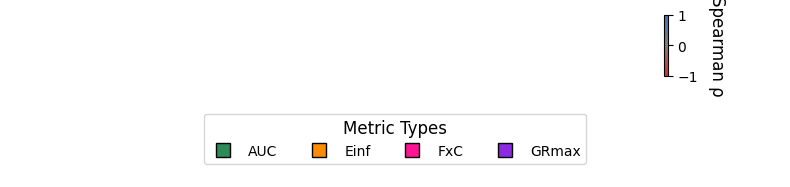

Creating individual heatmaps with color-coded labels...


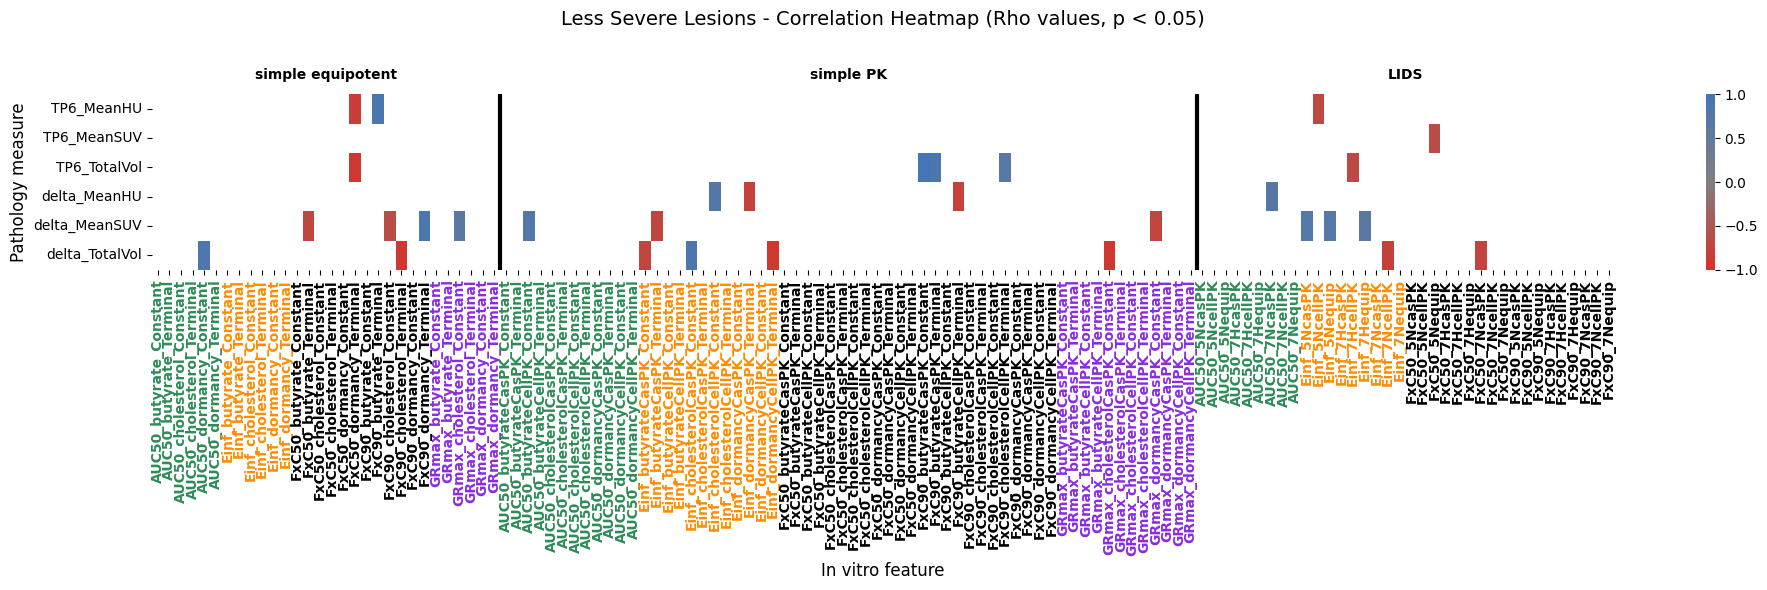

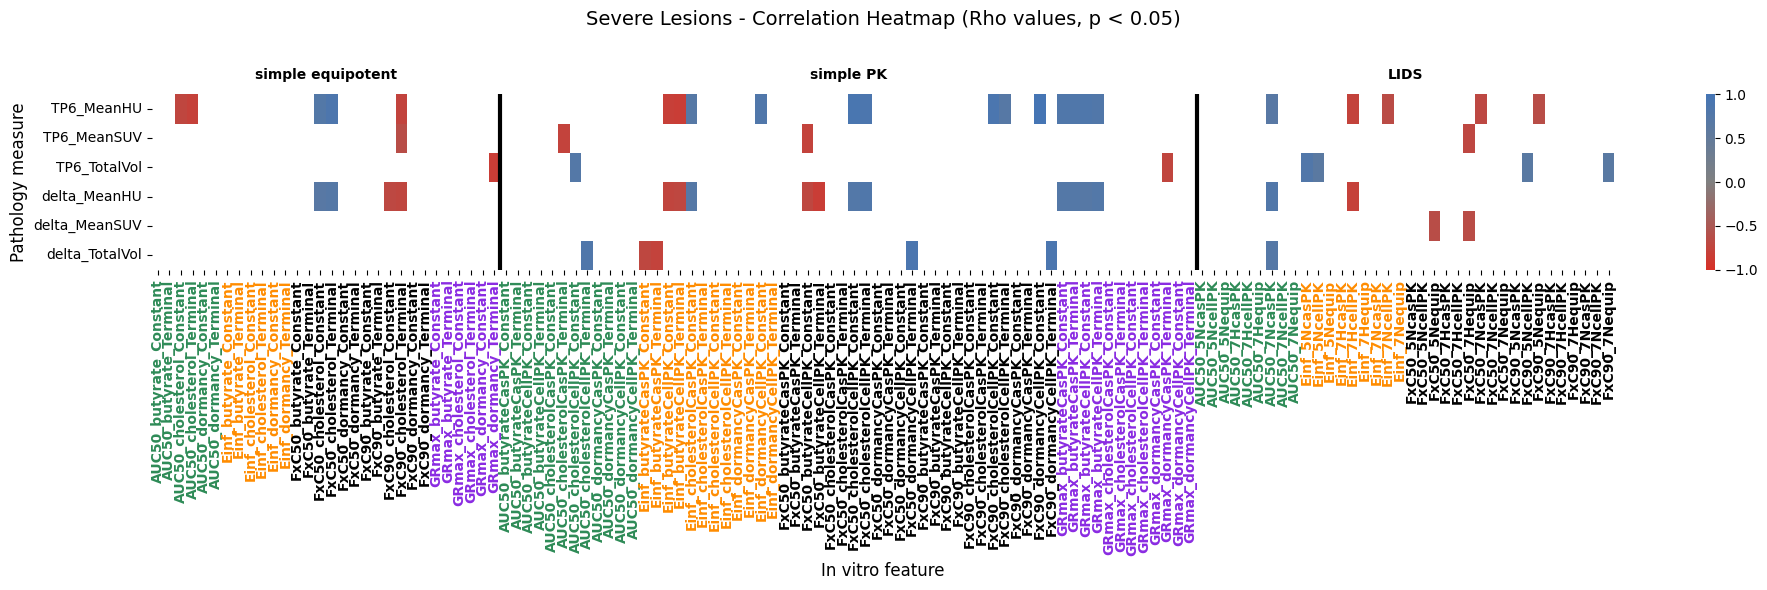

All plots generated successfully with color-coded X-axis labels!
Legend: AUC=Green, Einf=Orange, FxC=Magenta, GRmax=Purple


In [14]:
pathology_rows = ["TP6_MeanHU", 
                   "TP6_MeanSUV", 
                   "TP6_TotalVol",
                   "delta_MeanHU", 
                   "delta_MeanSUV",
                   "delta_TotalVol"]

# Example in vitro features to include (X-axis filtering)
# These should be actual in vitro feature names from your data
include_in_vitro_features = None  # Set to None to include all, or provide list like:
# include_in_vitro_features = ["AUC50 cholesterol (constant)", "FIC90 butyrate (terminal)", ...]

plotter = load_correlation_plotter()

# Create legend separately (now includes both correlation and metric color legends)
legend_fig = plotter.create_legend(orientation='vertical', include_metric_legend=True)
plt.show()

# Create individual heatmaps for each severity level with colored X-axis labels
print("Creating individual heatmaps with color-coded labels...")

# Less severe lesions - individual figure
fig_less_severe, ax_less_severe = plotter.create_individual_heatmap(
    severity='less_severe',
    plot_type='rho',
    title="Less Severe Lesions - Correlation Heatmap (Rho values, p < 0.05)",
    add_grid=True,
    color_xlabels=True,  # Enable color-coded X-axis labels
    pathology_rows=pathology_rows,  # Y-axis: which pathology measures to show
    include_features=include_in_vitro_features  # X-axis: which in vitro features to show
)
plt.show()

# Severe lesions - individual figure
fig_severe, ax_severe = plotter.create_individual_heatmap(
    severity='severe',
    plot_type='rho',
    title="Severe Lesions - Correlation Heatmap (Rho values, p < 0.05)",
    add_grid=True,
    color_xlabels=True,  # Enable color-coded X-axis labels
    pathology_rows=pathology_rows,  # Y-axis: which pathology measures to show
    include_features=include_in_vitro_features  # X-axis: which in vitro features to show
)
plt.show()

print("All plots generated successfully with color-coded X-axis labels!")
print("Legend: AUC=Green, Einf=Orange, FxC=Magenta, GRmax=Purple")